# 🍳 Optimizer Cookbook — Chapter 00: Setup & Baseline

This notebook sets up the full training pipeline that every subsequent optimizer notebook will reuse.

**What we do here:**
- Verify CUDA setup
- Load & preview CIFAR-10
- Define the baseline SimpleCNN model
- Train with vanilla SGD (no momentum) as the baseline
- Save loss/accuracy logs
- Plot training curves

Every other notebook will import from `models/` and `utils/` and only swap the optimizer.

---
## 0. Imports & CUDA Check

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm

# ── CUDA Check ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'CUDA version : {torch.version.cuda}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('WARNING: CUDA not found. Training will be slow on CPU.')

Using device : cuda
GPU          : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version : 11.8
VRAM         : 6.44 GB


---
## 1. Config — All Hyperparameters in One Place

> ✏️ Change only this cell to experiment with different settings.

In [3]:
# ── Training Config ─────────────────────────────────────────
BATCH_SIZE   = 128
NUM_EPOCHS   = 20
LEARNING_RATE = 0.01
NUM_WORKERS  = 2          # set to 0 if you get DataLoader errors on Windows
NUM_CLASSES  = 10
SEED         = 42

# ── Paths ────────────────────────────────────────────────────
DATA_DIR     = '../data'
RESULTS_DIR  = '../results/logs'
PLOTS_DIR    = '../results/plots'

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Config loaded ✓')

Config loaded ✓


---
## 2. Dataset — CIFAR-10

CIFAR-10 has **60,000 images** (32×32 RGB) across 10 classes:  
`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

- Train split: 50,000 images  
- Test split : 10,000 images

We apply standard normalization using CIFAR-10 mean/std.

In [4]:
# ── Transforms ───────────────────────────────────────────────
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ── Load Dataset ─────────────────────────────────────────────
train_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False,
                                              download=True, transform=test_transform)

train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                             shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASSES = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Classes       : {CLASSES}')

100%|██████████| 170M/170M [00:47<00:00, 3.58MB/s] 


Extracting ../data\cifar-10-python.tar.gz to ../data
Files already downloaded and verified
Train batches : 391
Test batches  : 79
Classes       : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


### 2.1 Preview a batch of CIFAR-10 images

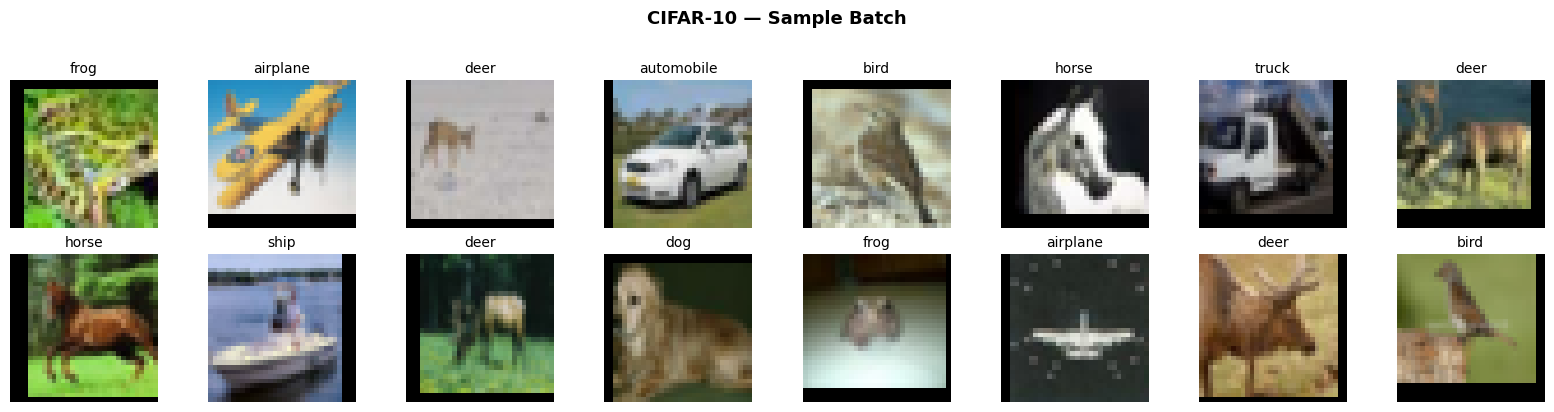

In [5]:
def imshow(img, title=None):
    # unnormalize
    mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR10_STD).view(3,1,1)
    img  = img * std + mean
    img  = img.numpy().transpose(1, 2, 0)
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    if title: plt.title(title, fontsize=10)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], title=CLASSES[labels[i]])
plt.suptitle('CIFAR-10 — Sample Batch', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/cifar10_sample.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Model — SimpleCNN

```
Input (3×32×32)
  → Conv(32) → BN → ReLU → MaxPool  →  16×16
  → Conv(64) → BN → ReLU → MaxPool  →   8×8
  → Conv(128)→ BN → ReLU → MaxPool  →   4×4
  → Flatten → FC(256) → Dropout → FC(10)
```

BatchNorm is included to stabilize training across all optimizers fairly.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16×16

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          #  8×8

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          #  4×4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Quick sanity check ───────────────────────────────────────
model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
out   = model(dummy)
print(f'Output shape : {out.shape}')   # should be [2, 10]

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {total_params:,}')

Output shape : torch.Size([2, 10])
Trainable params: 620,810


---
## 4. Training Utilities

Reusable `train_one_epoch` and `evaluate` functions.  
These are copied into `utils/trainer.py` — keep them in sync.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def run_training(model, train_loader, test_loader, optimizer, criterion,
                 num_epochs, device, optimizer_name='optimizer'):
    """Full training loop. Returns a DataFrame of per-epoch metrics."""
    history = []
    best_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)
        elapsed = time.time() - t0

        if val_acc > best_acc:
            best_acc = val_acc

        history.append({
            'epoch'     : epoch,
            'train_loss': train_loss,
            'train_acc' : train_acc,
            'val_loss'  : val_loss,
            'val_acc'   : val_acc,
            'time_s'    : elapsed,
        })

        print(f'Epoch [{epoch:02d}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
              f'Time: {elapsed:.1f}s')

    print(f'\n✓ Best Val Accuracy: {best_acc:.2f}%')
    df = pd.DataFrame(history)
    df.to_csv(f'{RESULTS_DIR}/{optimizer_name}_log.csv', index=False)
    print(f'✓ Log saved → results/logs/{optimizer_name}_log.csv')
    return df


print('Training utilities loaded ✓')

Training utilities loaded ✓


---
## 5. Plotting Utilities

In [8]:
def plot_training_curves(df, optimizer_name='SGD', save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves — {optimizer_name}', fontsize=14, fontweight='bold')

    # Loss
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss', linewidth=2, color='steelblue')
    ax1.plot(df['epoch'], df['val_loss'],   label='Val Loss',   linewidth=2, color='tomato', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(df['epoch'], df['train_acc'], label='Train Acc', linewidth=2, color='steelblue')
    ax2.plot(df['epoch'], df['val_acc'],   label='Val Acc',   linewidth=2, color='tomato', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save:
        path = f'{PLOTS_DIR}/{optimizer_name}_curves.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        print(f'Plot saved → {path}')
    plt.show()


print('Plotting utilities loaded ✓')

Plotting utilities loaded ✓


---
## 6. Baseline Training — Vanilla SGD

### Theory

**Stochastic Gradient Descent (SGD)** is the foundation of all deep learning optimization.

**Update rule:**
$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_{\theta} \mathcal{L}(\theta_t)$$

Where:
- $\theta$ = model parameters  
- $\eta$ = learning rate  
- $\nabla \mathcal{L}$ = gradient of the loss

**Key properties:**
- Same learning rate for all parameters
- No memory of past gradients
- Simple, well-understood, highly controllable

**When to use:** When you have a well-tuned LR schedule, large batch sizes, and plenty of compute. ResNets trained from scratch often use SGD + cosine annealing.

**When NOT to use:** Sparse features, NLP tasks, when you can't afford careful LR tuning.

In [9]:
# ── Instantiate fresh model + optimizer ──────────────────────
torch.manual_seed(SEED)
model     = SimpleCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

print(f'Optimizer : {optimizer.__class__.__name__}')
print(f'LR        : {LEARNING_RATE}')
print(f'Epochs    : {NUM_EPOCHS}')
print(f'Device    : {device}')
print('-' * 65)

Optimizer : SGD
LR        : 0.01
Epochs    : 20
Device    : cuda
-----------------------------------------------------------------


In [10]:
# ── Train ────────────────────────────────────────────────────
sgd_history = run_training(
    model        = model,
    train_loader = train_loader,
    test_loader  = test_loader,
    optimizer    = optimizer,
    criterion    = criterion,
    num_epochs   = NUM_EPOCHS,
    device       = device,
    optimizer_name = 'SGD_baseline'
)

Epoch [01/20] Train Loss: 1.7851 Acc: 35.36% | Val Loss: 1.4407 Acc: 47.82% | Time: 35.5s
Epoch [02/20] Train Loss: 1.4408 Acc: 47.38% | Val Loss: 1.2358 Acc: 55.85% | Time: 17.1s
Epoch [03/20] Train Loss: 1.3015 Acc: 53.00% | Val Loss: 1.1588 Acc: 57.92% | Time: 18.0s
Epoch [04/20] Train Loss: 1.2082 Acc: 56.66% | Val Loss: 1.0778 Acc: 61.70% | Time: 17.7s
Epoch [05/20] Train Loss: 1.1419 Acc: 59.53% | Val Loss: 0.9834 Acc: 65.33% | Time: 17.3s
Epoch [06/20] Train Loss: 1.0832 Acc: 61.65% | Val Loss: 1.0523 Acc: 62.33% | Time: 17.2s
Epoch [07/20] Train Loss: 1.0403 Acc: 63.09% | Val Loss: 1.0234 Acc: 63.92% | Time: 16.8s
Epoch [08/20] Train Loss: 1.0031 Acc: 64.21% | Val Loss: 0.9154 Acc: 67.48% | Time: 16.6s
Epoch [09/20] Train Loss: 0.9719 Acc: 65.51% | Val Loss: 0.9424 Acc: 66.42% | Time: 16.4s
Epoch [10/20] Train Loss: 0.9462 Acc: 66.64% | Val Loss: 0.8450 Acc: 70.56% | Time: 16.8s
Epoch [11/20] Train Loss: 0.9209 Acc: 67.36% | Val Loss: 0.8279 Acc: 70.82% | Time: 17.0s
Epoch [12/

Plot saved → ../results/plots/SGD_baseline_curves.png


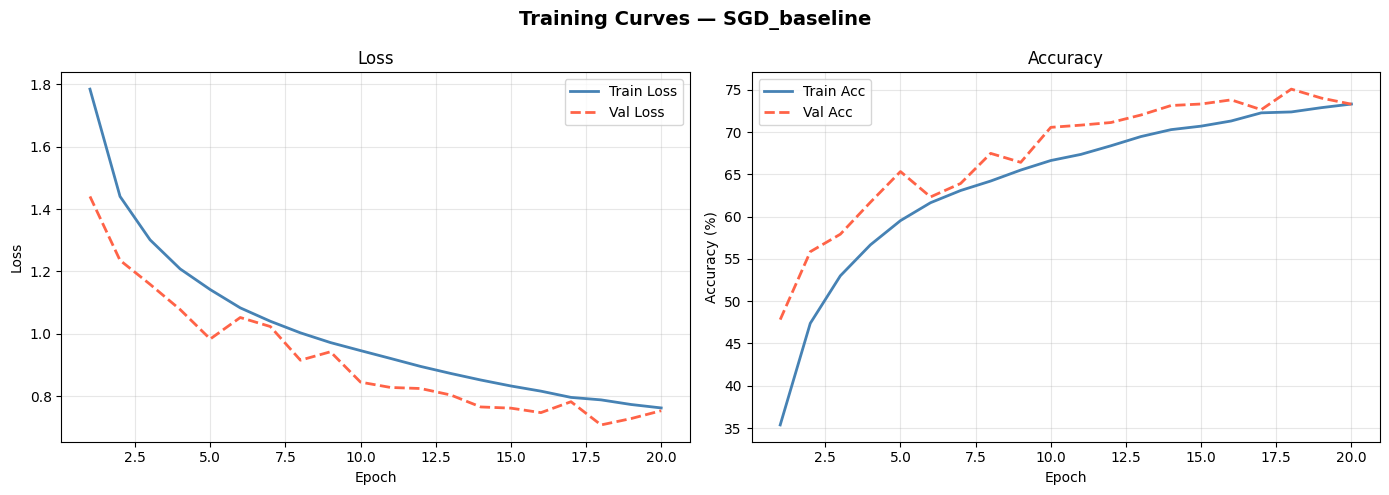

In [11]:
# ── Plot ─────────────────────────────────────────────────────
plot_training_curves(sgd_history, optimizer_name='SGD_baseline')

---
## 7. Results Summary

In [12]:
best_epoch = sgd_history.loc[sgd_history['val_acc'].idxmax()]

print('=' * 50)
print('  BASELINE — Vanilla SGD Summary')
print('=' * 50)
print(f"  Best Val Accuracy : {best_epoch['val_acc']:.2f}%")
print(f"  Best Val Loss     : {best_epoch['val_loss']:.4f}")
print(f"  Achieved at Epoch : {int(best_epoch['epoch'])}")
print(f"  Avg Time/Epoch    : {sgd_history['time_s'].mean():.1f}s")
print('=' * 50)
print()
print('📌 Observation:')
print('  Vanilla SGD converges slowly and is sensitive to LR.')
print('  This sets our baseline — all other optimizers should beat this.')

  BASELINE — Vanilla SGD Summary
  Best Val Accuracy : 75.08%
  Best Val Loss     : 0.7077
  Achieved at Epoch : 18
  Avg Time/Epoch    : 18.1s

📌 Observation:
  Vanilla SGD converges slowly and is sensitive to LR.
  This sets our baseline — all other optimizers should beat this.


---
## 8. What's Next?

| Notebook | Optimizer | Key concept |
|---|---|---|
| `01_sgd_momentum.ipynb` | SGD + Momentum | Accelerated gradients |
| `02_adagrad.ipynb`      | Adagrad         | Per-parameter adaptive LR |
| `03_rmsprop.ipynb`      | RMSprop         | Leaky Adagrad |
| `04_adam.ipynb`         | Adam            | Momentum + RMSprop |
| `05_adamw.ipynb`        | AdamW           | Decoupled weight decay |
| `06_radam.ipynb`        | RAdam           | Rectified variance |
| `07_comparison.ipynb`   | All             | Head-to-head plots |

Each notebook follows the **exact same structure** as this one — only the optimizer cell changes. All logs are saved to `results/logs/` for final comparison.